In this analysis I hope to evaluate whether attendance affects student performance while taking into account the other variables in this dataset. 

Limitations:
-This dataset does not specify the age, subject(s), location so it may not be a good representation of any specific population and is purely for practice in exploratory analysis


In [1]:
import numpy as np
import pandas as pd
import sqlite3
import os
os.getcwd()

'C:\\Users\\annad\\student_performance'

In [104]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [90]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [109]:
df.columns = df.columns.str.strip()
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [106]:
#checking for null values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [114]:
#counting rows with null values
len(df[df.isna().any(axis=1)])

0

229/6607 rows have missing values for variables: Parental_Education_Level, Teacher_Quality, Distance_from_Home (3.5% of all entries). This is a small percentage of the total sample. We could drop these rows if there is low correlation between missing valules and student performance (MCAR).

In [108]:
from scipy import stats
import math
df_mcar = df.copy()
df_mcar["tq_missing"] = df["Teacher_Quality"].isna().astype(int)
df_mcar["pe_missing"] = df["Parental_Education_Level"].isna().astype(int)
df_mcar["dh_missing"] = df["Distance_from_Home"].isna().astype(int)

df_mcar.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,tq_missing,pe_missing,dh_missing
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Positive,3,No,High School,Near,Male,67,0,0,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Negative,4,No,College,Moderate,Female,61,0,0,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Neutral,4,No,Postgraduate,Near,Male,74,0,0,0
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Negative,4,No,High School,Moderate,Male,71,0,0,0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Neutral,4,No,College,Near,Female,70,0,0,0


In [110]:
#T-test to check if null values for teacher quality are significantly correlated with exam scores
group1 = df_mcar[df_mcar["tq_missing"] == 1]["Exam_Score"]
group0 = df_mcar[df_mcar["tq_missing"] == 0]["Exam_Score"]

stats.ttest_ind(group1, group0, nan_policy="omit")

Ttest_indResult(statistic=-1.3580093600086731, pvalue=0.174507100610909)

In [111]:
#T-test to check if null values for parental education level are significantly correlated with exam scores
group1 = df_mcar[df_mcar["pe_missing"] == 1]["Exam_Score"]
group0 = df_mcar[df_mcar["pe_missing"] == 0]["Exam_Score"]

stats.ttest_ind(group1, group0, nan_policy="omit")

Ttest_indResult(statistic=-0.44217582743642847, pvalue=0.6583764541167714)

In [112]:
#T-test to check if null values for distance from home are significantly correlated with exam scores
group1 = df_mcar[df_mcar["dh_missing"] == 1]["Exam_Score"]
group0 = df_mcar[df_mcar["dh_missing"] == 0]["Exam_Score"]

stats.ttest_ind(group1, group0, nan_policy="omit")

Ttest_indResult(statistic=-1.697978053955864, pvalue=0.08955900766623251)

T-tests all result in p-values > 0.05 (although the p-value for distance from home is rather close ~0.09). Since all p-values indicate no statistically significant correlation between rows with null values and the exam scores we can assume the values are MCAR will drop the rows with null values.

In [40]:
#(df.isnull().mean() * 100).sort_values(ascending=False)

Parental_Education_Level      1.362192
Teacher_Quality               1.180566
Distance_from_Home            1.014076
Hours_Studied                 0.000000
Attendance                    0.000000
Gender                        0.000000
Learning_Disabilities         0.000000
Physical_Activity             0.000000
Peer_Influence                0.000000
School_Type                   0.000000
Family_Income                 0.000000
Tutoring_Sessions             0.000000
Internet_Access               0.000000
Motivation_Level              0.000000
Previous_Scores               0.000000
Sleep_Hours                   0.000000
Extracurricular_Activities    0.000000
Access_to_Resources           0.000000
Parental_Involvement          0.000000
Exam_Score                    0.000000
dtype: float64

In [113]:
#df with dropped null rows
df = df.dropna()

#df with missing in the place of null values
#df_m = df.fillna("Missing")

In [115]:
#check for dup rows --> no dups found
df.duplicated().sum()

0

In [116]:
#checking the variable types
print(df.dtypes)

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


In [78]:
#checking category consistancy
#for all categorical variables run this line to check for inconsistancies in spelling and spacing
#get all categorical variables from the output of prev cell
df["Gender"].value_counts()

Male      3814
Female    2793
Name: Gender, dtype: int64

No duplicate rows or inconsistancies in spelling and spacing in categorical variables

In [122]:
#check distribution for type int variables - looking for impossible values and extreme outliers
#rerun cell for each int variable
df["Exam_Score"].describe()
#df["Attendance"].hist()

count    6377.000000
mean       67.246825
std         3.891637
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: Exam_Score, dtype: float64

In [120]:
#displaying the rows where exam score is 101 (impossible)
#there is only one row so it will be dropped
df.loc[df["Exam_Score"] == 101]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [121]:
df = df.drop(index=1525)

In [124]:
df.to_csv("student_data_cleaned.csv", index=False)

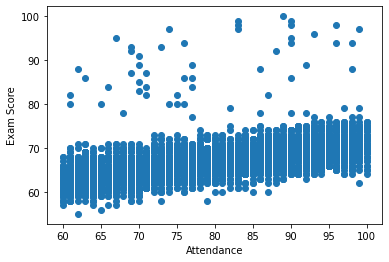

In [123]:
#checking for correlation between factors

import matplotlib.pyplot as plt

plt.scatter(df["Attendance"], df["Exam_Score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.show()